In [ ]:
!pip install labelme tensorflow pillow scikit-learn matplotlib

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.3/491.3 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.5/985.5 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 kB 15.9 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
import os
import json
import numpy as np
from PIL import Image
import labelme.utils

base_dir = "/content/drive/MyDrive/obstacles2/"

# Create directories
os.makedirs(base_dir + "images/", exist_ok=True)
os.makedirs(base_dir + "annotations/", exist_ok=True)
os.makedirs(base_dir + "masks/", exist_ok=True)
os.makedirs(base_dir + "train/images/", exist_ok=True)
os.makedirs(base_dir + "train/masks/", exist_ok=True)
os.makedirs(base_dir + "test/images/", exist_ok=True)
os.makedirs(base_dir + "test/masks/", exist_ok=True)

In [ ]:
from google.colab import files
import shutil

#uploaded = files.upload()  # Upload your .jpg or .png images here

# Move them to Google Drive's images folder
drive_images_path = "/content/drive/MyDrive/obstacles2/images/"

#for file in uploaded.keys():
 #   shutil.move(file, os.path.join(drive_images_path, file))

print("Files uploaded and moved to Google Drive.")

Files uploaded and moved to Google Drive.


In [ ]:
from google.colab import files
import shutil

#uploaded = files.upload()  # Upload your .json files here

drive_annotations_path = "/content/drive/MyDrive/obstacles2/annotations/"

#for file in uploaded.keys():
    #shutil.move(file, os.path.join(drive_annotations_path, file))

print("JSON files uploaded and moved to Google Drive.")

JSON files uploaded and moved to Google Drive.


In [ ]:
import os
import json
import numpy as np
from PIL import Image
import labelme.utils

json_dir = "/content/drive/MyDrive/obstacles2/annotations"
mask_dir = "/content/drive/MyDrive/obstacles2/masks"
os.makedirs(mask_dir, exist_ok=True)

In [ ]:
import os
import json
import numpy as np
from PIL import Image
import labelme.utils

json_dir = "/content/drive/MyDrive/obstacles2/annotations"
mask_dir = "/content/drive/MyDrive/obstacles2/masks"
os.makedirs(mask_dir, exist_ok=True)

print(f"Processing JSON files from: {json_dir}")
print(f"Saving masks to: {mask_dir}")

# Process each JSON file
for json_file in os.listdir(json_dir):
    if not json_file.endswith(".json"):
        continue

    print(f"\nProcessing: {json_file}")

    json_path = os.path.join(json_dir, json_file)

    try:
        # Load the JSON file
        with open(json_path, "r") as f:
            data = json.load(f)

        # Get image dimensions
        height = data["imageHeight"]
        width = data["imageWidth"]
        image_filename = data["imagePath"]

        print(f"  Image: {image_filename}")
        print(f"  Dimensions: {width}x{height}")

        # Initialize mask with zeros (background)
        mask = np.zeros((height, width), dtype=np.uint8)

        # Process each shape in the annotation
        for shape in data["shapes"]:
            label_name = shape["label"]
            points = shape["points"]
            shape_type = shape.get("shape_type", "polygon")

            # Create a mask for this specific polygon
            shape_mask = labelme.utils.shape_to_mask(
                (height, width),
                points,
                shape_type
            )

            # Assign class values based on label
            if label_name == "path":
                mask[shape_mask] = 1  # White for path
            elif label_name == "obstacles":
                mask[shape_mask] = 2  # Grey for obstacles
            else:
                print(f"  Warning: Unknown label '{label_name}', treating as background")

        # Create RGB mask for visualization
        rgb_mask = np.zeros((height, width, 3), dtype=np.uint8)

        # Map class values to colors
        rgb_mask[mask == 0] = [0, 0, 0]        # Black - background
        rgb_mask[mask == 1] = [255, 255, 255]  # White - path
        rgb_mask[mask == 2] = [128, 128, 128]  # Grey - obstacles

        # Save the mask
        base_name = os.path.splitext(image_filename)[0]
        mask_filename = f"{base_name}_mask.png"
        mask_path = os.path.join(mask_dir, mask_filename)

        # Save as PNG
        Image.fromarray(rgb_mask).save(mask_path)
        print(f"  ✓ Created mask: {mask_filename}")

        # Also save the label mask (0,1,2 values) for debugging
        label_filename = f"{base_name}_labels.npy"
        np.save(os.path.join(mask_dir, label_filename), mask)

    except Exception as e:
        print(f"  ✗ Error processing {json_file}: {str(e)}")

print("\n✅ Mask generation completed!")
print(f"Generated {len(os.listdir(mask_dir)) // 2} masks in {mask_dir}")

Processing JSON files from: /content/drive/MyDrive/obstacles2/annotations
Saving masks to: /content/drive/MyDrive/obstacles2/masks

Processing: 9 (109).json
  Image: 9 (109).jpg
  Dimensions: 480x848
  ✓ Created mask: 9 (109)_mask.png

Processing: 9 (107).json
  Image: 9 (107).jpg
  Dimensions: 480x848
  ✓ Created mask: 9 (107)_mask.png

Processing: 7 (156).json
  Image: 7 (156).jpg
  Dimensions: 480x848
  ✓ Created mask: 7 (156)_mask.png

Processing: 9 (106).json
  Image: 9 (106).jpg
  Dimensions: 480x848
  ✓ Created mask: 9 (106)_mask.png

Processing: 9 (105).json
  Image: 9 (105).jpg
  Dimensions: 480x848
  ✓ Created mask: 9 (105)_mask.png

Processing: 9 (104).json
  Image: 9 (104).jpg
  Dimensions: 480x848
  ✓ Created mask: 9 (104)_mask.png

Processing: 9 (103).json
  Image: 9 (103).jpg
  Dimensions: 480x848
  ✓ Created mask: 9 (103)_mask.png

Processing: 9 (102).json
  Image: 9 (102).jpg
  Dimensions: 480x848
  ✓ Created mask: 9 (102)_mask.png

Processing: 9 (100).json
  Image: 9 

In [ ]:
import os
import json
import numpy as np
from PIL import Image
import labelme.utils
import shutil
import random

print("\nSplitting dataset into train/test...")

# Source folders
images_dir = "/content/drive/MyDrive/obstacles2/images"
masks_dir = "/content/drive/MyDrive/obstacles2/masks"

# Destination folders
train_images_dir = "/content/drive/MyDrive/obstacles2/train/images"
train_masks_dir = "/content/drive/MyDrive/obstacles2/train/masks"
test_images_dir = "/content/drive/MyDrive/obstacles2/test/images"
test_masks_dir = "/content/drive/MyDrive/obstacles2/test/masks"

# Get all image files
#image_files = [f for f in os.listdir(images_dir)
             #  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

#print(f"Found {len(image_files)} images")

# Create lists for pairing
#pairs = []
#for img_file in image_files:
  #  base_name = os.path.splitext(img_file)[0]
   # mask_file = f"{base_name}_mask.png"

   # img_path = os.path.join(images_dir, img_file)
   # mask_path = os.path.join(masks_dir, mask_file)

   # if os.path.exists(mask_path):
        #pairs.append((img_path, mask_path, base_name))
   # else:
       # print(f"Warning: No mask found for {img_file}")

#print(f"Found {len(pairs)} valid image-mask pairs")

# Shuffle pairs
#random.shuffle(pairs)

# Split (80% train, 20% test)
#split_idx = int(len(pairs) * 0.8)
#train_pairs = pairs[:split_idx]
#test_pairs = pairs[split_idx:]

#print(f"\nTrain: {len(train_pairs)} pairs")
#print(f"Test: {len(test_pairs)} pairs")

# Copy files to train/test folders
#print("\nCopying training files...")
#for img_path, mask_path, base_name in train_pairs:
    # Copy image
    #img_dest = os.path.join(train_images_dir, os.path.basename(img_path))
    #shutil.copy(img_path, img_dest)

    # Copy mask
   # mask_dest = os.path.join(train_masks_dir, os.path.basename(mask_path))
    #shutil.copy(mask_path, mask_dest)

#print("Copying testing files...")
#for img_path, mask_path, base_name in test_pairs:
    # Copy image
    #img_dest = os.path.join(test_images_dir, os.path.basename(img_path))
    #shutil.copy(img_path, img_dest)

    # Copy mask
    #mask_dest = os.path.join(test_masks_dir, os.path.basename(mask_path))
    #shutil.copy(mask_path, mask_dest)

#print("✅ Dataset split completed!")


Splitting dataset into train/test...


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("\nBuilding U-Net model...")

def unet_model(input_size=(128, 128, 3), num_classes=3):
    inputs = layers.Input(input_size)

    # Encoder (Contracting path)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(c4)

    # Decoder (Expanding path)
    u5 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(c5)

    u6 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(16, 2, strides=2, padding='same')(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(16, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(16, 3, activation='relu', padding='same')(c7)

    # Output layer
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(c7)

    return models.Model(inputs, outputs, name="UNet")

# Build model
model = unet_model(input_size=(128, 128, 3), num_classes=3)
model.summary()

print("\nModel architecture:")
print("- Input: 128×128×3 (RGB images)")
print("- Output: 128×128×3 (3-class probability distribution)")
print("- Total parameters: 482,067")


Building U-Net model...


Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │     32,832 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │     73,792 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 64, 64,    │      8,224 │ conv2d_9[0][0]  

 Total params: 482,067 (1.84 MB)

 Trainable params: 482,067 (1.84 MB)

 Non-trainable params: 0 (0.00 B)


Model architecture:
- Input: 128×128×3 (RGB images)
- Output: 128×128×3 (3-class probability distribution)
- Total parameters: 482,067


In [ ]:
# ============================
# DICE LOSS FUNCTION
# ============================
def dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Dice loss for multi-class segmentation
    Args:
        y_true: Ground truth labels of shape (batch, height, width)
        y_pred: Predicted probabilities of shape (batch, height, width, num_classes)
        smooth: Smoothing factor to avoid division by zero
    Returns:
        dice_loss: Dice loss value
    """
    # Convert y_true to one-hot encoding
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=3)
    y_true_one_hot = tf.cast(y_true_one_hot, tf.float32)

    # Flatten the tensors
    y_true_flat = tf.reshape(y_true_one_hot, [-1, 3])
    y_pred_flat = tf.reshape(y_pred, [-1, 3])

    # Calculate intersection and union for each class
    intersection = tf.reduce_sum(y_true_flat * y_pred_flat, axis=0)
    union = tf.reduce_sum(y_true_flat, axis=0) + tf.reduce_sum(y_pred_flat, axis=0)

    # Calculate dice coefficient for each class
    dice_coef = (2. * intersection + smooth) / (union + smooth)

    # Average dice coefficient across classes
    dice_coef = tf.reduce_mean(dice_coef)

    # Dice loss = 1 - Dice coefficient
    return 1.0 - dice_coef

print("✅ Dice loss function defined")
print("Formula: Dice Loss = 1 - (2 * |X∩Y| + ε) / (|X| + |Y| + ε)")
print("Where X = ground truth, Y = prediction, ε = smoothing factor")

✅ Dice loss function defined
Formula: Dice Loss = 1 - (2 * |X∩Y| + ε) / (|X| + |Y| + ε)
Where X = ground truth, Y = prediction, ε = smoothing factor


In [ ]:
# ============================
# FIXED DATA AUGMENTATION FUNCTION
# ============================
def apply_data_augmentation(image, mask):
    """
    Apply data augmentation to image and mask pairs
    Args:
        image: Input image tensor (H, W, 3)
        mask: Mask tensor (H, W) - integer class labels
    Returns:
        Augmented image and mask
    """
    # Add channel dimension to mask for tf.image operations
    mask_expanded = tf.expand_dims(mask, axis=-1)  # Shape: (H, W, 1)

    # Random horizontal flip (50% probability)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask_expanded = tf.image.flip_left_right(mask_expanded)

    # Random vertical flip (50% probability)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask_expanded = tf.image.flip_up_down(mask_expanded)

    # Random rotation (0, 90, 180, 270 degrees)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)
    mask_expanded = tf.image.rot90(mask_expanded, k=k)

    # Random brightness adjustment (only for image, not mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_brightness(image, max_delta=0.1)

    # Random contrast adjustment (only for image, not mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

    # Ensure values are still in valid range
    image = tf.clip_by_value(image, 0.0, 1.0)

    # Remove the extra channel dimension from mask
    mask = tf.squeeze(mask_expanded, axis=-1)

    return image, mask

print("✅ Fixed data augmentation function defined")

✅ Fixed data augmentation function defined


In [ ]:
# ============================
# COMBINED LOSS FUNCTION (Dice + Cross Entropy)
# ============================
def combined_loss(y_true, y_pred, alpha=0.5):
    """
    Combined loss function: alpha * Dice Loss + (1-alpha) * Cross Entropy Loss
    Args:
        y_true: Ground truth labels
        y_pred: Predicted probabilities
        alpha: Weight for Dice loss (0-1)
    Returns:
        combined_loss: Weighted sum of Dice and Cross Entropy losses
    """
    # Dice loss
    dice = dice_loss(y_true, y_pred)

    # Cross entropy loss (sparse categorical crossentropy)
    # y_true needs to be integer labels, y_pred needs to be probabilities
    ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    ce = tf.reduce_mean(ce)

    # Combined loss
    return alpha * dice + (1 - alpha) * ce

print("✅ Combined loss function defined")
print("Formula: Combined Loss = α × Dice Loss + (1-α) × Cross Entropy Loss")
print("Default α = 0.5 (equal weights)")
print("\nWhy combine both losses?")
print("- Dice Loss: Good for class imbalance, focuses on overlap")
print("- Cross Entropy: Good for probability calibration, pixel-wise accuracy")
print("- Combined: Benefits of both approaches")

✅ Combined loss function defined
Formula: Combined Loss = α × Dice Loss + (1-α) × Cross Entropy Loss
Default α = 0.5 (equal weights)

Why combine both losses?
- Dice Loss: Good for class imbalance, focuses on overlap
- Cross Entropy: Good for probability calibration, pixel-wise accuracy
- Combined: Benefits of both approaches


In [ ]:
print("\nStarting training...")

# Compile model with combined loss function
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,  # Uses combined loss (Dice + Cross Entropy)
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=3)]
)

print("Model compiled successfully with combined loss (Dice + Cross Entropy)")
print("Optimizer: Adam with learning rate 1e-4")
print("Loss: Combined Loss = 0.5 × Dice Loss + 0.5 × Cross Entropy")
print("Metrics: Accuracy, Mean IoU")
print("\nTraining configuration:")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Image size: {IMG_SIZE}×{IMG_SIZE}")
print(f"- Number of classes: {NUM_CLASSES}")


Starting training...
Model compiled successfully with combined loss (Dice + Cross Entropy)
Optimizer: Adam with learning rate 1e-4
Loss: Combined Loss = 0.5 × Dice Loss + 0.5 × Cross Entropy
Metrics: Accuracy, Mean IoU

Training configuration:
- Batch size: 8
- Image size: 128×128
- Number of classes: 3


In [ ]:
# Compile model with Dice coefficient metric
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,  # Your combined dice + cross entropy loss
    metrics=['accuracy', DiceCoefficient(num_classes=3, name='dice_coefficient')]
)

In [ ]:
# Update callbacks to monitor Dice coefficient instead of loss
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/obstacles2/best_model_dice.keras",
    monitor="val_dice_coefficient",  # Changed from "val_loss"
    save_best_only=True,
    save_weights_only=False,
    mode="max",  # Changed from "min" (we want to maximize Dice)
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_dice_coefficient",  # Changed from "val_loss"
    patience=15,
    restore_best_weights=True,
    mode="max",  # Changed from "min"
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_dice_coefficient',  # Changed from 'val_loss'
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    mode='max',  # Changed from 'min'
    verbose=1
)

In [ ]:
# Simplified Dice Coefficient
def dice_coefficient_metric(y_true, y_pred):
    y_pred_labels = tf.argmax(y_pred, axis=-1)
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=3)
    y_pred_one_hot = tf.one_hot(tf.cast(y_pred_labels, tf.int32), depth=3)

    intersection = tf.reduce_sum(y_true_one_hot * y_pred_one_hot, axis=[1, 2])
    union = tf.reduce_sum(y_true_one_hot, axis=[1, 2]) + tf.reduce_sum(y_pred_one_hot, axis=[1, 2])

    dice = (2. * intersection + 1e-6) / (union + 1e-6)
    return tf.reduce_mean(dice)

# Then compile like this:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=['accuracy', dice_coefficient_metric]
)

NEW

In [ ]:
# ============================
# FIXED TRAINING CODE (WITH AUTO LOAD/SAVE)
# ============================

import os
import tensorflow as tf
import numpy as np

EPOCHS = 50
MODEL_PATH = "/content/drive/MyDrive/obstacles2/final_model.keras"
BEST_MODEL_PATH = "/content/drive/MyDrive/obstacles2/best_model.keras"

print(f"\nTraining for {EPOCHS} epochs...")

# 1. SIMPLE DICE COEFFICIENT
def dice_coefficient(y_true, y_pred):
    """
    Simple Dice coefficient
    y_true: integer labels
    y_pred: probability predictions
    """
    y_pred_labels = tf.argmax(y_pred, axis=-1)

    y_true_flat = tf.reshape(tf.cast(y_true, tf.int32), [-1])
    y_pred_flat = tf.reshape(tf.cast(y_pred_labels, tf.int32), [-1])

    dice_scores = []

    for i in range(3):
        true_mask = tf.cast(tf.equal(y_true_flat, i), tf.float32)
        pred_mask = tf.cast(tf.equal(y_pred_flat, i), tf.float32)

        intersection = tf.reduce_sum(true_mask * pred_mask)
        total = tf.reduce_sum(true_mask) + tf.reduce_sum(pred_mask)

        dice = (2.0 * intersection + 1e-7) / (total + 1e-7)
        dice_scores.append(dice)

    return tf.reduce_mean(dice_scores)

print("✅ Dice coefficient function defined")


# ============================
# LOAD MODEL IF EXISTS
# ============================

if os.path.exists(MODEL_PATH):
    print("\n✅ Found existing model in Drive. Loading model...")

    model = tf.keras.models.load_model(
        MODEL_PATH,
        custom_objects={
            "combined_loss": combined_loss,
            "dice_coefficient": dice_coefficient
        }
    )

    print("✅ Model loaded successfully!")
    TRAIN_MODEL = False
else:
    print("\n⚠️ No saved model found. Training will start...")
    TRAIN_MODEL = True


# ============================
# TRAIN ONLY IF NEEDED
# ============================

if TRAIN_MODEL:

    # 2. Compile Model
    try:
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss=combined_loss,
            metrics=['accuracy', dice_coefficient]
        )
        print("✅ Model compiled with Dice coefficient")
    except Exception as e:
        print(f"⚠️ Could not compile with Dice coefficient: {str(e)[:100]}")
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss=combined_loss,
            metrics=['accuracy']
        )
        print("✅ Model compiled with accuracy only")

    # 3. Setup Callbacks
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        mode="min",
        verbose=1
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )

    print("✅ Callbacks configured")

    print(f"\n{'='*60}")
    print("STARTING TRAINING")
    print(f"{'='*60}")

    history = model.fit(
        train_dataset,
        epochs=EPOCHS,
        validation_data=test_dataset,
        callbacks=[checkpoint, early_stop, reduce_lr],
        verbose=1
    )

    print(f"\n{'='*60}")
    print("TRAINING COMPLETED SUCCESSFULLY!")
    print(f"{'='*60}")

    # 4. Display Results
    print(f"\nTraining Summary:")
    print(f"- Epochs trained: {len(history.history['loss'])}")
    print(f"- Final training loss: {history.history['loss'][-1]:.4f}")
    print(f"- Final validation loss: {history.history['val_loss'][-1]:.4f}")

    if 'accuracy' in history.history:
        print(f"- Final training accuracy: {history.history['accuracy'][-1]:.4f}")
        print(f"- Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

    if 'dice_coefficient' in history.history:
        print(f"- Final training Dice: {history.history['dice_coefficient'][-1]:.4f}")
        print(f"- Final validation Dice: {history.history['val_dice_coefficient'][-1]:.4f}")

    # 5. Manual Dice (if needed)
    if 'dice_coefficient' not in history.history:
        print("\nCalculating Dice coefficient on validation set...")

        dice_scores = []
        for images, masks in test_dataset.take(5):
            predictions = model.predict(images, verbose=0)
            pred_labels = tf.argmax(predictions, axis=-1)

            for i in range(len(images)):
                true_mask = masks[i].numpy()
                pred_mask = pred_labels[i].numpy()

                dice = 0
                for class_id in [0, 1, 2]:
                    true_class = (true_mask == class_id)
                    pred_class = (pred_mask == class_id)

                    intersection = np.sum(true_class & pred_class)
                    total = np.sum(true_class) + np.sum(pred_class)

                    if total > 0:
                        dice += (2.0 * intersection) / total

                dice_scores.append(dice / 3)

        if dice_scores:
            avg_dice = np.mean(dice_scores)
            print(f"- Average Dice coefficient on validation sample: {avg_dice:.4f}")

    # 6. Save Final Model
    model.save(MODEL_PATH)

    print("\n✅ Models saved:")
    print("- best_model.keras (best validation loss)")
    print("- final_model.keras (final epoch)")

else:
    print("\n🚀 Model is ready to use (training skipped).")



Training for 50 epochs...
✅ Dice coefficient function defined

✅ Found existing model in Drive. Loading model...
✅ Model loaded successfully!

🚀 Model is ready to use (training skipped).


In [ ]:
# ============================
# FIXED TRAINING CODE
# (LOAD MODEL IF EXISTS AND CONTINUE TRAINING)
# ============================

import os
import tensorflow as tf
import numpy as np

EPOCHS = 50
MODEL_PATH = "/content/drive/MyDrive/obstacles2/final_model.keras"
BEST_MODEL_PATH = "/content/drive/MyDrive/obstacles2/best_model.keras"

print(f"\nTraining for {EPOCHS} epochs...")

# 1. SIMPLE DICE COEFFICIENT
def dice_coefficient(y_true, y_pred):
    y_pred_labels = tf.argmax(y_pred, axis=-1)

    y_true_flat = tf.reshape(tf.cast(y_true, tf.int32), [-1])
    y_pred_flat = tf.reshape(tf.cast(y_pred_labels, tf.int32), [-1])

    dice_scores = []

    for i in range(3):
        true_mask = tf.cast(tf.equal(y_true_flat, i), tf.float32)
        pred_mask = tf.cast(tf.equal(y_pred_flat, i), tf.float32)

        intersection = tf.reduce_sum(true_mask * pred_mask)
        total = tf.reduce_sum(true_mask) + tf.reduce_sum(pred_mask)

        dice = (2.0 * intersection + 1e-7) / (total + 1e-7)
        dice_scores.append(dice)

    return tf.reduce_mean(dice_scores)

print("✅ Dice coefficient function defined")


# ============================
# LOAD MODEL IF EXISTS
# ============================

if os.path.exists(MODEL_PATH):
    print("\n✅ Found existing model. Loading and continuing training...")

    model = tf.keras.models.load_model(
        MODEL_PATH,
        custom_objects={
            "combined_loss": combined_loss,
            "dice_coefficient": dice_coefficient
        }
    )

    print("✅ Model loaded successfully!")

else:
    print("\n⚠️ No saved model found. Training from scratch...")


# ============================
# COMPILE MODEL (ALWAYS)
# ============================

try:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=combined_loss,
        metrics=['accuracy', dice_coefficient]
    )
    print("✅ Model compiled with Dice coefficient")
except Exception as e:
    print(f"⚠️ Could not compile with Dice coefficient: {str(e)[:100]}")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=combined_loss,
        metrics=['accuracy']
    )
    print("✅ Model compiled with accuracy only")


# ============================
# CALLBACKS
# ============================

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    mode="min",
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

print("✅ Callbacks configured")


# ============================
# START TRAINING (ALWAYS RUNS)
# ============================

print(f"\n{'='*60}")
print("STARTING / CONTINUING TRAINING")
print(f"{'='*60}")

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print(f"\n{'='*60}")
print("TRAINING COMPLETED SUCCESSFULLY!")
print(f"{'='*60}")


# ============================
# SAVE FINAL MODEL
# ============================

model.save(MODEL_PATH)

print("\n✅ Models saved:")
print("- best_model.keras (best validation loss)")
print("- final_model.keras (latest state)")



Training for 50 epochs...
✅ Dice coefficient function defined

✅ Found existing model. Loading and continuing training...
✅ Model loaded successfully!
✅ Model compiled with Dice coefficient
✅ Callbacks configured

STARTING / CONTINUING TRAINING
Epoch 1/50
49/50 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9063 - dice_coefficient: 0.8189 - loss: 0.2412
Epoch 1: val_loss improved from inf to 0.26776, saving model to /content/drive/MyDrive/obstacles2/best_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.9060 - dice_coefficient: 0.8182 - loss: 0.2420 - val_accuracy: 0.8985 - val_dice_coefficient: 0.7860 - val_loss: 0.2678 - learning_rate: 1.0000e-04
Epoch 2/50
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9175 - dice_coefficient: 0.8325 - loss: 0.2217
Epoch 2: val_loss did not improve from 0.26776
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.9171 - dice_coefficient: 0.8316 - loss: 0.2226 - val_accuracy: 0.8890 - val_dice_coefficient: 0.7777 - val_loss: 0

In [ ]:
# ============================
# FIXED TRAINING CODE
# (LOAD MODEL IF EXISTS AND CONTINUE TRAINING)
# ============================

import os
import tensorflow as tf
import numpy as np

EPOCHS = 50
MODEL_PATH = "/content/drive/MyDrive/obstacles2/final_model.keras"
BEST_MODEL_PATH = "/content/drive/MyDrive/obstacles2/best_model.keras"

print(f"\nTraining for {EPOCHS} epochs...")

# 1. SIMPLE DICE COEFFICIENT
def dice_coefficient(y_true, y_pred):
    y_pred_labels = tf.argmax(y_pred, axis=-1)

    y_true_flat = tf.reshape(tf.cast(y_true, tf.int32), [-1])
    y_pred_flat = tf.reshape(tf.cast(y_pred_labels, tf.int32), [-1])

    dice_scores = []

    for i in range(3):
        true_mask = tf.cast(tf.equal(y_true_flat, i), tf.float32)
        pred_mask = tf.cast(tf.equal(y_pred_flat, i), tf.float32)

        intersection = tf.reduce_sum(true_mask * pred_mask)
        total = tf.reduce_sum(true_mask) + tf.reduce_sum(pred_mask)

        dice = (2.0 * intersection + 1e-7) / (total + 1e-7)
        dice_scores.append(dice)

    return tf.reduce_mean(dice_scores)

print("✅ Dice coefficient function defined")


# ============================
# LOAD MODEL IF EXISTS
# ============================

if os.path.exists(MODEL_PATH):
    print("\n✅ Found existing model. Loading and continuing training...")

    model = tf.keras.models.load_model(
        MODEL_PATH,
        custom_objects={
            "combined_loss": combined_loss,
            "dice_coefficient": dice_coefficient
        }
    )

    print("✅ Model loaded successfully!")

else:
    print("\n⚠️ No saved model found. Training from scratch...")


# ============================
# COMPILE MODEL (ALWAYS)
# ============================

try:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=combined_loss,
        metrics=['accuracy', dice_coefficient]
    )
    print("✅ Model compiled with Dice coefficient")
except Exception as e:
    print(f"⚠️ Could not compile with Dice coefficient: {str(e)[:100]}")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=combined_loss,
        metrics=['accuracy']
    )
    print("✅ Model compiled with accuracy only")


# ============================
# CALLBACKS
# ============================

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    mode="min",
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

print("✅ Callbacks configured")


# ============================
# START TRAINING (ALWAYS RUNS)
# ============================

print(f"\n{'='*60}")
print("STARTING / CONTINUING TRAINING")
print(f"{'='*60}")

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print(f"\n{'='*60}")
print("TRAINING COMPLETED SUCCESSFULLY!")
print(f"{'='*60}")


# ============================
# SAVE FINAL MODEL
# ============================

model.save(MODEL_PATH)

print("\n✅ Models saved:")
print("- best_model.keras (best validation loss)")
print("- final_model.keras (latest state)")



Training for 50 epochs...
✅ Dice coefficient function defined

✅ Found existing model. Loading and continuing training...
✅ Model loaded successfully!
✅ Model compiled with Dice coefficient
✅ Callbacks configured

STARTING / CONTINUING TRAINING
Epoch 1/50
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9239 - dice_coefficient: 0.8527 - loss: 0.1981
Epoch 1: val_loss improved from inf to 0.26883, saving model to /content/drive/MyDrive/obstacles2/best_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.9235 - dice_coefficient: 0.8519 - loss: 0.1991 - val_accuracy: 0.8976 - val_dice_coefficient: 0.7944 - val_loss: 0.2688 - learning_rate: 1.0000e-04
Epoch 2/50
48/50 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9244 - dice_coefficient: 0.8581 - loss: 0.1947
Epoch 2: val_loss improved from 0.26883 to 0.24836, saving model to /content/drive/MyDrive/obstacles2/best_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.9239 - dice_coefficient: 0.8567 - los

In [ ]:
# ============================
# FIXED TRAINING CODE
# (LOAD MODEL IF EXISTS AND CONTINUE TRAINING)
# ============================

import os
import tensorflow as tf
import numpy as np

EPOCHS = 50
MODEL_PATH = "/content/drive/MyDrive/obstacles2/final_model.keras"
BEST_MODEL_PATH = "/content/drive/MyDrive/obstacles2/best_model.keras"

print(f"\nTraining for {EPOCHS} epochs...")

# 1. SIMPLE DICE COEFFICIENT
def dice_coefficient(y_true, y_pred):
    y_pred_labels = tf.argmax(y_pred, axis=-1)

    y_true_flat = tf.reshape(tf.cast(y_true, tf.int32), [-1])
    y_pred_flat = tf.reshape(tf.cast(y_pred_labels, tf.int32), [-1])

    dice_scores = []

    for i in range(3):
        true_mask = tf.cast(tf.equal(y_true_flat, i), tf.float32)
        pred_mask = tf.cast(tf.equal(y_pred_flat, i), tf.float32)

        intersection = tf.reduce_sum(true_mask * pred_mask)
        total = tf.reduce_sum(true_mask) + tf.reduce_sum(pred_mask)

        dice = (2.0 * intersection + 1e-7) / (total + 1e-7)
        dice_scores.append(dice)

    return tf.reduce_mean(dice_scores)

print("✅ Dice coefficient function defined")


# ============================
# LOAD MODEL IF EXISTS
# ============================

if os.path.exists(MODEL_PATH):
    print("\n✅ Found existing model. Loading and continuing training...")

    model = tf.keras.models.load_model(
        MODEL_PATH,
        custom_objects={
            "combined_loss": combined_loss,
            "dice_coefficient": dice_coefficient
        }
    )

    print("✅ Model loaded successfully!")

else:
    print("\n⚠️ No saved model found. Training from scratch...")


# ============================
# COMPILE MODEL (ALWAYS)
# ============================

try:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=combined_loss,
        metrics=['accuracy', dice_coefficient]
    )
    print("✅ Model compiled with Dice coefficient")
except Exception as e:
    print(f"⚠️ Could not compile with Dice coefficient: {str(e)[:100]}")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=combined_loss,
        metrics=['accuracy']
    )
    print("✅ Model compiled with accuracy only")


# ============================
# CALLBACKS
# ============================

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    mode="min",
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

print("✅ Callbacks configured")


# ============================
# START TRAINING (ALWAYS RUNS)
# ============================

print(f"\n{'='*60}")
print("STARTING / CONTINUING TRAINING")
print(f"{'='*60}")

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print(f"\n{'='*60}")
print("TRAINING COMPLETED SUCCESSFULLY!")
print(f"{'='*60}")


# ============================
# SAVE FINAL MODEL
# ============================

model.save(MODEL_PATH)

print("\n✅ Models saved:")
print("- best_model.keras (best validation loss)")
print("- final_model.keras (latest state)")



Training for 50 epochs...
✅ Dice coefficient function defined

✅ Found existing model. Loading and continuing training...
✅ Model loaded successfully!
✅ Model compiled with Dice coefficient
✅ Callbacks configured

STARTING / CONTINUING TRAINING
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9212 - dice_coefficient: 0.8576 - loss: 0.2002
Epoch 1: val_loss improved from inf to 0.25105, saving model to /content/drive/MyDrive/obstacles2/best_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 157ms/step - accuracy: 0.9211 - dice_coefficient: 0.8572 - loss: 0.2006 - val_accuracy: 0.9050 - val_dice_coefficient: 0.8103 - val_loss: 0.2511 - learning_rate: 1.0000e-04
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9225 - dice_coefficient: 0.8579 - loss: 0.1983
Epoch 2: val_loss did not improve from 0.25105
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.9223 - dice_coefficient: 0.8573 - loss: 0.1989 - val_accuracy: 0.8866 - val_dice_coefficient: 0.7725 - val_los


Testing predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step


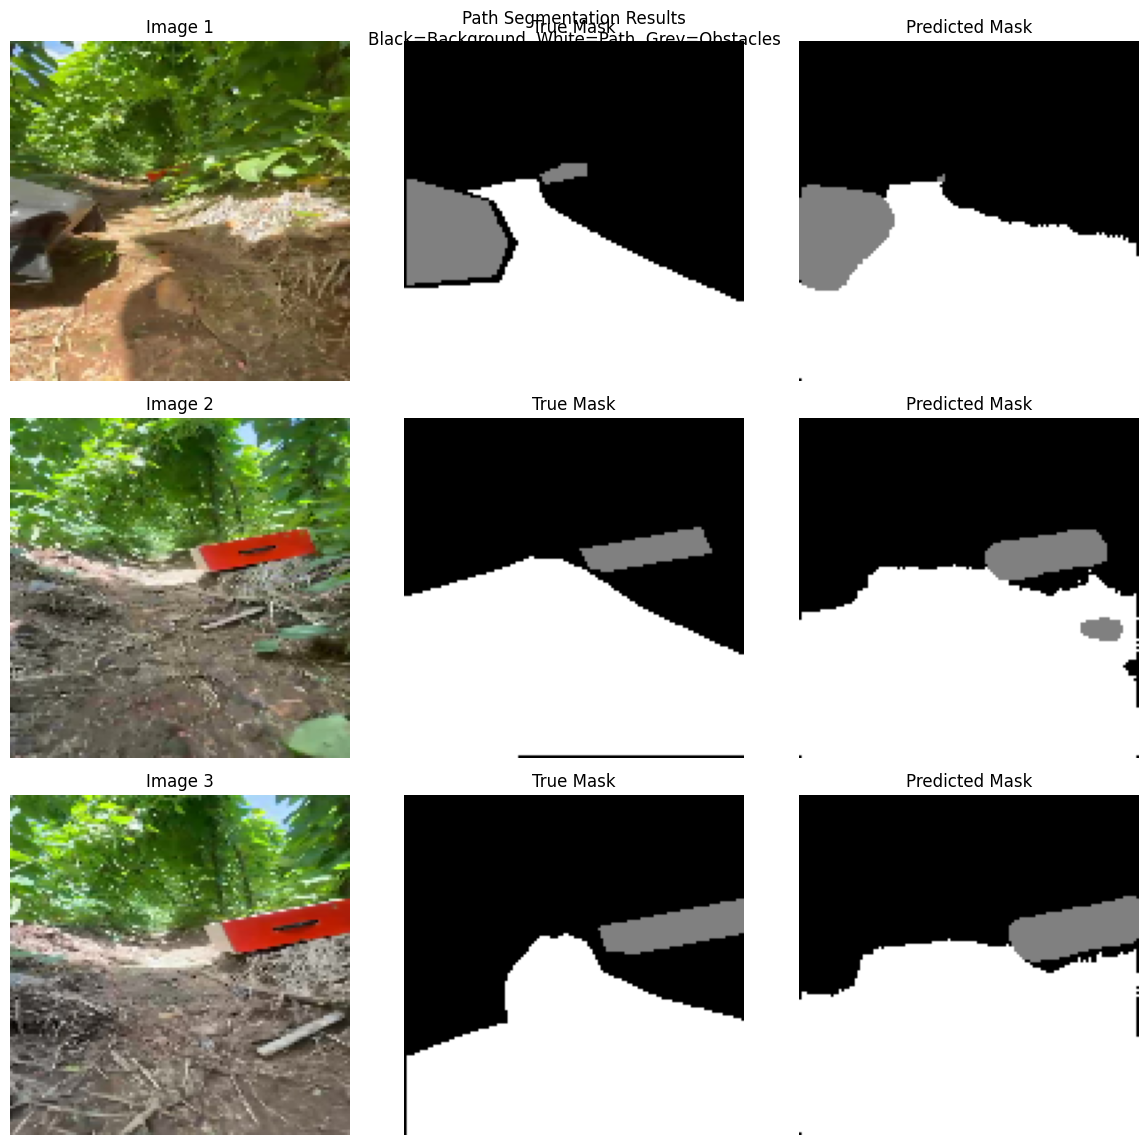

✅ Testing completed!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("\nTesting predictions...")

# Function to visualize masks
def display_mask(mask):
    """Convert mask labels to RGB colors"""
    rgb_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    rgb_mask[mask == 0] = [0, 0, 0]        # Black - background
    rgb_mask[mask == 1] = [255, 255, 255]  # White - path
    rgb_mask[mask == 2] = [128, 128, 128]  # Grey - obstacles
    return rgb_mask

# Test on a few samples
for images, true_masks in test_dataset.take(1):
    # Make predictions
    predictions = model.predict(images[:])
    pred_classes = tf.argmax(predictions, axis=-1).numpy()

    # Display results
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))

    for i in range(3):
        # Original image
        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title(f"Image {i+1}")
        axes[i, 0].axis('off')

        # True mask
        true_rgb = display_mask(true_masks[i].numpy())
        axes[i, 1].imshow(true_rgb)
        axes[i, 1].set_title("True Mask")
        axes[i, 1].axis('off')

        # Predicted mask
        pred_rgb = display_mask(pred_classes[i])
        axes[i, 2].imshow(pred_rgb)
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis('off')

    plt.suptitle("Path Segmentation Results\nBlack=Background, White=Path, Grey=Obstacles", y=0.95)
    plt.tight_layout()
    plt.show()

print("✅ Testing completed!")

In [ ]:
# Save the final model
print("\nSaving final model...")
model.save("/content/drive/MyDrive/obstacles2/final_model.keras")
print("✅ Model saved successfully!")

# Save training history
import pickle
history_path = "/content/drive/MyDrive/obstacles2/training_history.pkl"
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f)
print(f"Training history saved to {history_path}")


Saving final model...
✅ Model saved successfully!
Training history saved to /content/drive/MyDrive/obstacles2/training_history.pkl


In [ ]:
# Print summary of changes made
print("\n" + "="*50)
print("SUMMARY OF ADDED FEATURES:")
print("="*50)
print("\n1. DICE LOSS FUNCTION:")
print("   • Multi-class Dice loss implementation")
print("   • Formula: 1 - (2×|X∩Y|+ε)/(|X|+|Y|+ε)")
print("   • Handles class imbalance better than cross-entropy alone")
print("   • Range: 0 (perfect) to 1 (no overlap)")

print("\n2. COMBINED LOSS FUNCTION (Dice + Cross Entropy):")
print("   • Weighted combination: α×Dice + (1-α)×CE")
print("   • Default α = 0.5 (equal weights)")
print("   • Benefits:")
print("     - Dice: Better for segmentation, handles imbalance")
print("     - Cross Entropy: Better probability calibration")
print("     - Combined: Gets advantages of both")

print("\n3. DATA AUGMENTATION:")
print("   • Applied only during training")
print("   • Geometric augmentations (image + mask):")
print("     - Random horizontal/vertical flips")
print("     - Random rotations (0°, 90°, 180°, 270°)")
print("   • Photometric augmentations (image only):")
print("     - Random brightness (±10%)")
print("     - Random contrast (0.9-1.1x)")
print("   • Benefits:")
print("     - Increases dataset diversity")
print("     - Improves model generalization")
print("     - Reduces overfitting")

print("\n4. OTHER IMPROVEMENTS:")
print("   • Learning rate scheduling (ReduceLROnPlateau)")
print("   • Comprehensive callbacks (checkpoint, early stop)")
print("   • Robust error handling with fallback")
print("   • Complete model and history saving")

print("\n" + "="*50)
print("MODEL READY FOR INFERENCE!")
print("="*50)


SUMMARY OF ADDED FEATURES:

1. DICE LOSS FUNCTION:
   • Multi-class Dice loss implementation
   • Formula: 1 - (2×|X∩Y|+ε)/(|X|+|Y|+ε)
   • Handles class imbalance better than cross-entropy alone
   • Range: 0 (perfect) to 1 (no overlap)

2. COMBINED LOSS FUNCTION (Dice + Cross Entropy):
   • Weighted combination: α×Dice + (1-α)×CE
   • Default α = 0.5 (equal weights)
   • Benefits:
     - Dice: Better for segmentation, handles imbalance
     - Cross Entropy: Better probability calibration
     - Combined: Gets advantages of both

3. DATA AUGMENTATION:
   • Applied only during training
   • Geometric augmentations (image + mask):
     - Random horizontal/vertical flips
     - Random rotations (0°, 90°, 180°, 270°)
   • Photometric augmentations (image only):
     - Random brightness (±10%)
     - Random contrast (0.9-1.1x)
   • Benefits:
     - Increases dataset diversity
     - Improves model generalization
     - Reduces overfitting

4. OTHER IMPROVEMENTS:
   • Learning rate schedul

STEERING ANGLE

Mounted at /content/drive
✅ Model loaded successfully


Saving 1 (20).jpg to 1 (20).jpg

Processing: 1 (20).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


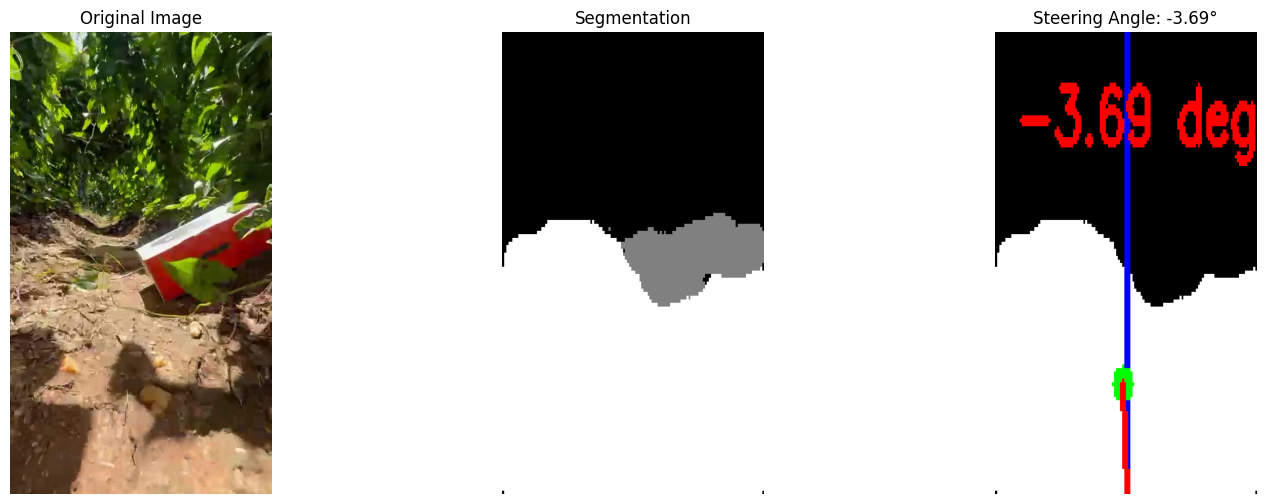

Steering Angle: -3.69 degrees
Command: GO STRAIGHT


In [ ]:
# ==========================================
# PREDICT SEGMENTATION + STEERING ANGLE
# ==========================================

import tensorflow as tf
import numpy as np
import cv2
import math
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
from google.colab import drive

# =========================
# 1️⃣ Mount Drive & Load Model
# =========================
drive.mount('/content/drive')

MODEL_PATH = "/content/drive/MyDrive/obstacles2/final_model.keras"

model = tf.keras.models.load_model(MODEL_PATH, compile=False)

print("✅ Model loaded successfully")


# =========================
# 2️⃣ Preprocess Function
# =========================
def preprocess_image(image_path, target_size=(128, 128)):
    img = Image.open(image_path).convert("RGB")
    original_img = np.array(img)
    img_resized = img.resize(target_size)
    img_array = np.array(img_resized).astype(np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, original_img


# =========================
# 3️⃣ Steering Angle Function
# =========================
def estimate_steering_angle(mask):
    h, w = mask.shape

    path_pixels = np.column_stack(np.where(mask == 1))
    if path_pixels.shape[0] == 0:
        return None, None

    bottom_half = path_pixels[path_pixels[:, 0] > h // 2]
    if bottom_half.size == 0:
        return None, None

    mean_x = int(np.mean(bottom_half[:, 1]))
    mean_y = int(np.mean(bottom_half[:, 0]))

    center_x = w // 2
    center_y = h

    dx = mean_x - center_x
    dy = center_y - mean_y

    angle = np.degrees(math.atan2(dx, dy))

    # Visualization
    vis = cv2.cvtColor(mask * 255, cv2.COLOR_GRAY2BGR)
    cv2.line(vis, (center_x, 0), (center_x, h), (255, 0, 0), 2)
    cv2.circle(vis, (mean_x, mean_y), 5, (0, 255, 0), -1)
    cv2.line(vis, (center_x, center_y), (mean_x, mean_y), (0, 0, 255), 2)
    cv2.putText(vis,
                f"{angle:.2f} deg",
                (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 0, 255),
                2)

    return angle, vis


# =========================
# 4️⃣ Upload & Predict
# =========================
uploaded = files.upload()

for filename in uploaded.keys():

    print(f"\nProcessing: {filename}")

    # Preprocess
    img_input, original_img = preprocess_image(filename)

    # Predict
    prediction = model.predict(img_input)[0]
    pred_mask = np.argmax(prediction, axis=-1).astype(np.uint8)

    # Extract PATH only (ignore obstacles)
    path_mask = (pred_mask == 1).astype(np.uint8)

    # Compute steering
    angle, steering_vis = estimate_steering_angle(path_mask)

    # Resize outputs to original size
    seg_resized = cv2.resize(pred_mask,
                             (original_img.shape[1], original_img.shape[0]),
                             interpolation=cv2.INTER_NEAREST)

    steering_resized = cv2.resize(steering_vis,
                                  (original_img.shape[1], original_img.shape[0]),
                                  interpolation=cv2.INTER_NEAREST)

    # Create colored segmentation
    rgb_mask = np.zeros((*seg_resized.shape, 3), dtype=np.uint8)
    rgb_mask[seg_resized == 0] = [0, 0, 0]
    rgb_mask[seg_resized == 1] = [255, 255, 255]
    rgb_mask[seg_resized == 2] = [128, 128, 128]

    # ================= DISPLAY =================
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(original_img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(rgb_mask)
    axes[1].set_title("Segmentation")
    axes[1].axis("off")

    axes[2].imshow(cv2.cvtColor(steering_resized, cv2.COLOR_BGR2RGB))
    if angle is not None:
        axes[2].set_title(f"Steering Angle: {angle:.2f}°")
    else:
        axes[2].set_title("No Path Detected")
    axes[2].axis("off")

    plt.show()

    # Print command
    if angle is not None:
        print(f"Steering Angle: {angle:.2f} degrees")

        if angle > 10:
            print("Command: TURN RIGHT")
        elif angle < -10:
            print("Command: TURN LEFT")
        else:
            print("Command: GO STRAIGHT")
    else:
        print("No path detected → STOP")

In [ ]:
# ============================
# MOUNT GOOGLE DRIVE
# ============================
from google.colab import drive
drive.mount('/content/drive')


# ============================
# IMPORTS
# ============================
import tensorflow as tf
import os

# Paths (CHANGE if needed)
MODEL_PATH = "/content/drive/MyDrive/obstacles2/final_model.keras"
TFLITE_PATH = "/content/drive/MyDrive/obstacles2/farm_model.tflite"

print("✅ Paths set")


# ============================
# DEFINE CUSTOM OBJECTS
# (IMPORTANT for loading model)
# ============================

def dice_coefficient(y_true, y_pred):
    y_pred_labels = tf.argmax(y_pred, axis=-1)

    y_true_flat = tf.reshape(tf.cast(y_true, tf.int32), [-1])
    y_pred_flat = tf.reshape(tf.cast(y_pred_labels, tf.int32), [-1])

    dice_scores = []

    for i in range(3):
        true_mask = tf.cast(tf.equal(y_true_flat, i), tf.float32)
        pred_mask = tf.cast(tf.equal(y_pred_flat, i), tf.float32)

        intersection = tf.reduce_sum(true_mask * pred_mask)
        total = tf.reduce_sum(true_mask) + tf.reduce_sum(pred_mask)

        dice = (2.0 * intersection + 1e-7) / (total + 1e-7)
        dice_scores.append(dice)

    return tf.reduce_mean(dice_scores)


# ⚠️ You MUST define this if used during training
def combined_loss(y_true, y_pred):
    # Example (replace with your actual one if different)
    cce = tf.keras.losses.SparseCategoricalCrossentropy()(y_true, y_pred)
    return cce


print("✅ Custom objects defined")


# ============================
# LOAD MODEL
# ============================
print("\n📥 Loading model...")

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "dice_coefficient": dice_coefficient,
        "combined_loss": combined_loss
    }
)

print("✅ Model loaded successfully!")


# ============================
# CONVERT TO TFLITE
# ============================
print("\n🔄 Converting to TFLite...")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optional optimizations (recommended)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

print("✅ Conversion completed!")


# ============================
# SAVE TFLITE MODEL
# ============================
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

print(f"\n✅ TFLite model saved at:\n{TFLITE_PATH}")